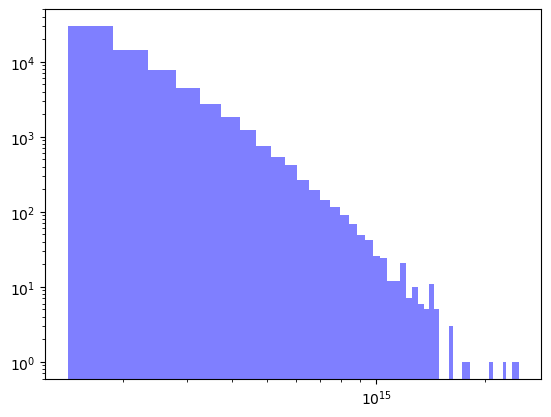

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq

#box size in mpc/h
L=2688
volume=L**3

#create particles
x,y,z=np.genfromtxt('cluster_Box0_z0.txt',usecols=(1,2,3),unpack=True)/1000  #sono in kpc/h!!!, faccio/1000
mass=np.genfromtxt('cluster_Box0_z0.txt',usecols=(7),unpack=True)
n_points=len(x)
density=n_points/volume

plt.hist(mass,bins=50,color='blue',alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

Sono aloni giganti, a z=0

Deltah=f(Deltam)
Deltah=Sommatoria(bi x Deltam^i)   dove bi=bias iesimo
e poi faccio <Deltah(x) Deltah(x+r)>=b1<Deltam(x),Deltam(x+r)>

Epsilon_h^L=(b1^2) x (epsilon_m^L(r))
se b1^2=1 aloni correlati tanto quanto materia quindi mi aspetto un grafico che scende verso dx con un piccolo picco, con plot con il bias che coincide con quello senza bias
se b1^2>1 è più facile la coppia di oggetti scelta rispetto ad una coppia di un altro tipo di oggetti, quindi il grafico con bias  è più alto di quello senza bias 
se b1^2<1  si trova il grafico con bias più basso

In [3]:
n_cells=64 #è un nostro parametro, def fino  ache scala voglio misuare Pk, meglio se è multiplo di 2 per dopo
cell_size=L/n_cells
print("Cell size: ",cell_size) #mpc/h

#compute the mean density
cell_mean_density=n_points/n_cells**3
print("Mean density in the cell: ",cell_mean_density) #mpc**-3/h**3

#create density grid with histogramdd
grid,edges=np.histogramdd((x,y,z),bins=(n_cells,n_cells,n_cells),range=((0,L),(0,L),(0,L)))

#compute the density field
density_field=(grid-cell_mean_density)/cell_mean_density 

Cell size:  42.0
Mean density in the cell:  0.24880599975585938


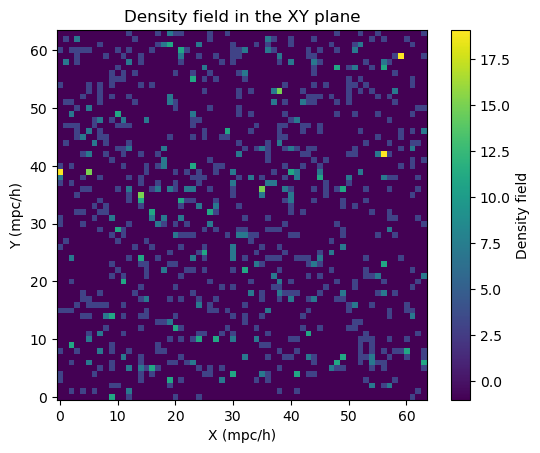

In [4]:
plt.imshow(density_field[:,:,0],origin='lower',cmap='viridis')
plt.colorbar(label='Density field')
plt.title('Density field in the XY plane')
plt.xlabel('X (mpc/h)')
plt.ylabel('Y (mpc/h)')
plt.show()

In [5]:
#compute the delta in fourier space
delta_k=rfftn(density_field)/n_cells**3  #normmalizzo per il number di celle  
#è oggetto grande: (64,64,33) e vale che f(-k)=f*(k) e f(k)=f(-k) (coniugato)

#create the k grid
kF=2*np.pi/L  #fondamental frequency in mpc**-1/h
H=L/n_cells
kN=np.pi/H   #Nyquist frequency in mpc**-1/h
kx=fftfreq(n_cells,d=1/n_cells)*kF
ky=fftfreq(n_cells,d=1/n_cells)*kF
kz=rfftfreq(n_cells,d=1/n_cells)*kF #ATTENZIONE

KX,KY,KZ=np.meshgrid(kx,ky,kz)
KK=np.sqrt(KX**2+KY**2+KZ**2)  

#fftfreq(n_cells,d=1/n_cells) 

In [6]:
#calcolo spettro di pot su griglia
pk_grid=delta_k*np.conjugate(delta_k)*volume  #metto il volume perchè non sono nel continuo ma nel discreto
#ora devo fare binning griglia per avere p(|k|)
#Binning
c=1
k_edges=np.arange(kF,kN,c*kF) 
k_bins=0.5*(k_edges[1:]+k_edges[:-1])
#print("k edges: ",k_edges)

/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


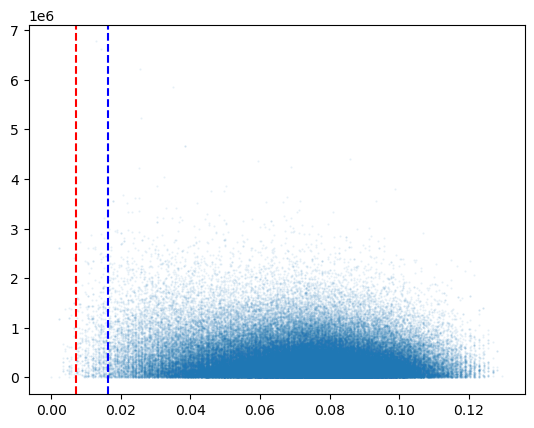

In [7]:
plt.plot(KK.flatten(),pk_grid.flatten(),'.',markersize=1,alpha=0.1)
plt.axvline(k_edges[2], color='red', linestyle='--', label='k bins')
plt.axvline(k_edges[6], color='blue', linestyle='--', label='k bins')


In [8]:
pk_averaged=np.zeros(k_bins.shape)
k_averaged=np.zeros(k_bins.shape)

for i in range(len(k_bins)):
    mask=(KK.flatten()>k_edges[i]) & (KK.flatten()<k_edges[i+1])
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask].real)
    k_averaged[i]=np.mean(KK.flatten()[mask])
    print(k_averaged[i],pk_averaged[i])

0.0035533640796179037 411638.6697722159
0.005700784360095065 551640.3674318702
0.008172820569802518 686036.7924252558
0.010505623637017802 699230.1235270499
0.012949678793327559 605526.5558464495
0.01511488716115336 729848.552070677
0.017449780952069203 651515.274061911
0.019750449466914784 621529.2841676936
0.022203394016669476 639180.5001832162
0.02449389436068027 571552.6157330014
0.0268168449742968 560904.9639735152
0.029127266250347957 548699.5247392725
0.03156475778240329 534582.7086839131
0.03392727296846349 497793.7016781485
0.036216767061726746 500784.8724007586
0.03851763910205504 464788.5189032612
0.04088657678219153 459195.3079874002
0.04319844717793945 456142.5937397235
0.0455581285592049 427466.39793915465
0.04790345569842132 435919.2976039409
0.05025930752246956 419841.93588467897
0.05255466176249511 412247.550349556
0.05490458720059724 393357.9456143061
0.057217253122645105 396608.9406525029
0.05957845803578802 398271.89433170937
0.06191428622522097 394781.1840631316
0.

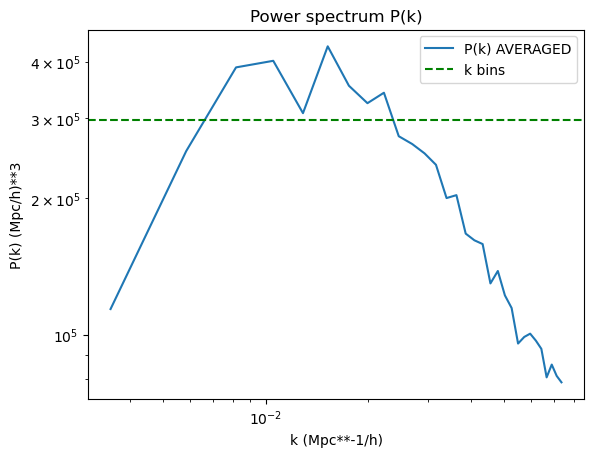

In [9]:
plt.loglog(k_bins,pk_averaged-1./density,label='P(k) AVERAGED')
plt.axhline(1./density, color='green', linestyle='--', label='k bins')
plt.xlabel('k (Mpc**-1/h)')
plt.ylabel('P(k) (Mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

ora aggiungo la predizione teorica, ed uso camb

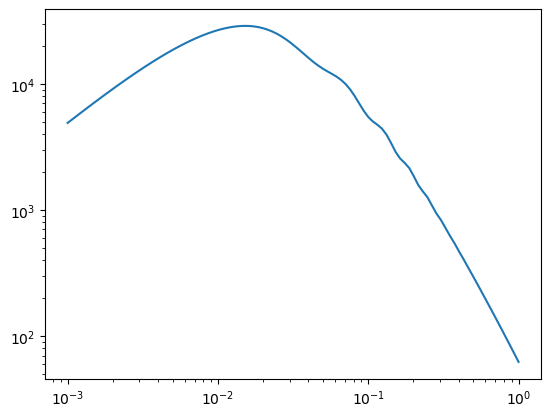

In [ ]:
import camb
camb_params=camb.CAMBparams()
h=0.704
ombh2=0.022
omega_m=0.272
omch2=omega_m* h**2 -ombh2
camb_params.set_cosmology(H0=70.4,ombh2=0.022,omch2=omch2,mnu=0,num_massive_neutrinos=0)
camb_params.InitPower.set_params(ns=0.963)
camb_params.set_matter_power(redshifts=[0.,],kmax=1.0)

camb_results=camb.get_results(camb_params)
k,z,pk=camb_results.get_matter_power_spectrum(minkh=0.001,maxkh=1.0)

sigma8_z0=camb_results.get_sigma8_0()
pk_renorm=pk[0]*(0.809)**2/sigma8_z0**2
plt.loglog(k,pk_renorm)



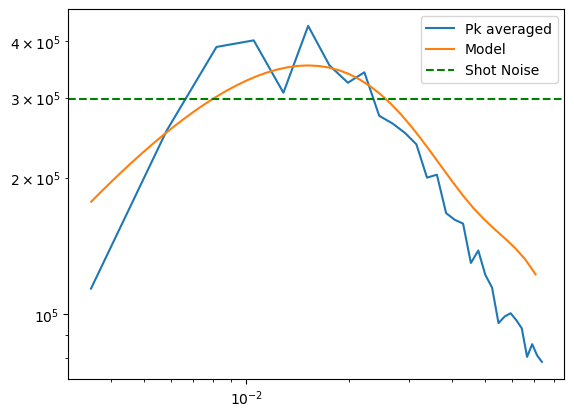

In [13]:
plt.loglog(k_bins,pk_averaged-1./density, label='Pk averaged')  #blue
#plt.loglog(k_bins,pk_averaged, label='Pk averaged')  #blue

b=3.5
plt.loglog(k[(k>k_bins[0]) &(k<k_bins[-1])],b**2*pk_renorm[(k>k_bins[0])&(k<k_bins[-1])], label='Model')  #arancione
#plt.loglog(k[(k>k_bins[0]) &(k<k_bins[-1])],b**2*pk_renorm[(k>k_bins[0])&(k<k_bins[-1])]+1./density, label='Camb')  #arancione

plt.axhline(1./density,linestyle='--',label='Shot Noise',color='green')  #verde


plt.legend()
plt.show()

per aloni di mat oscura b>1, ovvero aloni tendono a stare più vicini, e quindi ,dato che galassie stanno dentro aloni, il campo di densità è più biassato del campo di materia
oggetti piu massivi stanno piu vicini, e piu facile trovarli grossi e vicini

posso rifarlo con il catalogo galassie, invece che cluster e si osserva che se ci metto sopra camb sono circa simili, errore iniza ed esserci a grandi scale di x